# Solver Benchmark — 2026-04-08

Running four solvers on matrices from `result_10000-2568220` (golf ball meshes, nv from ~10K to ~2.5M vertices).

**Two experiment groups:**
- `golf_ball_1` — single-threaded baseline (`OMP_NUM_THREADS=1` for OMP solvers, `mpirun -np 1` for MPI solvers)
- `golf_ball_8` — 8-way parallel (`OMP_NUM_THREADS=8` or `mpirun -np 8`)

**Solvers:**
- **AMGCL** — OMP-parallel iterative
- **Eigen::PardisoLDLT** — OMP-parallel direct (skipped for mat_sz > 727119, too slow)
- **Hypre_mpi** — MPI-parallel iterative (newly fixed: proper row partitioning + `MPI_Allgatherv`)
- **Trilinos** — MPI-parallel iterative

For each group we plot **elapse time vs matrix size (rows)** on log-log axes, with log-linear fit lines to show scaling slope.

In [19]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    "AMGCL":             "#d62728",
    "Eigen::PardisoLDLT": "#1f77b4",
    "Hypre_mpi":         "#2ca02c",
    "Trilinos":          "#ff7f0e",
}
# Longest prefix first so "Eigen::PardisoLDLT" matches before "Eigen::"
SOLVER_PREFIXES = sorted(SOLVER_COLORS.keys(), key=len, reverse=True)

# All matrices in this benchmark are stiffness matrices generated by PolyFEM
# with the Hessian projected to PSD (forced positive-definite for safe iterative solving).
DATA_SOURCE_NOTE = "Matrices: PolyFEM forced PSD"


def load_all_logs(log_dir):
    """Parse every *.log under log_dir, return DataFrame(solver, mat_sz, nnz, elapse_time)."""
    rows = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for prefix in SOLVER_PREFIXES:
            if fname.startswith(prefix + "_"):
                solver = prefix
                break
        if solver is None:
            continue
        try:
            entries = parse_log_file(os.path.join(log_dir, fname), solver)
        except Exception as ex:
            print(f"Skipping {fname}: {ex}")
            continue
        for e in entries:
            if e.get("mat_sz") and e.get("elapse_time"):
                rows.append({
                    "solver":      solver,
                    "mat_sz":      e["mat_sz"],
                    "nnz":         e.get("nnz"),
                    "elapse_time": e["elapse_time"],
                    "num_iterations": e.get("num_iterations"),
                })
    return pd.DataFrame(rows)


def plot_time_vs_mat_sz(df, title, figsize=(10, 6)):
    """Scatter elapse_time vs mat_sz for each solver + log-log linear fit on per-mat_sz means."""
    fig, ax = plt.subplots(figsize=figsize)
    for solver in SOLVER_PREFIXES:
        g = df[df["solver"] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g["mat_sz"], g["elapse_time"], s=16, alpha=0.5, color=color,
                   label=f"{solver} (n={len(g)})")

        # Log-log linear fit on the AVERAGE elapse_time per distinct mat_sz
        g_mean = g.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g_mean) >= 3:
            log_x = np.log10(g_mean["mat_sz"].values)
            log_y = np.log10(g_mean["elapse_time"].values)
            slope, intercept = np.polyfit(log_x, log_y, 1)
            x_fit = np.logspace(log_x.min(), log_x.max(), 200)
            y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
            ax.plot(x_fit, y_fit, "--", color=color, linewidth=1.5, alpha=0.8,
                    label=f"  fit (slope={slope:.2f}, on means)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Matrix Size (rows, log scale)", fontsize=12)
    ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
    full_title = f"{title}\n{DATA_SOURCE_NOTE}  ·  fit lines = log-linear over mean elapse_time per mat_sz"
    ax.set_title(full_title, fontsize=11)
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    return fig, ax


BASE = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220'
print(f"Base dir: {BASE}")
print(f"Groups: {sorted(os.listdir(BASE))}")

Base dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220
Groups: ['golf_ball_1', 'golf_ball_8']


## Group 1: `golf_ball_1` — single-threaded baseline

Group golf_ball_1: 653 entries
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210  121.759576
Eigen::PardisoLDLT  29988   727119   144  337.403828
Hypre_mpi           29988  2890827   170  493.581412
Trilinos            29988   686154   129  702.404264


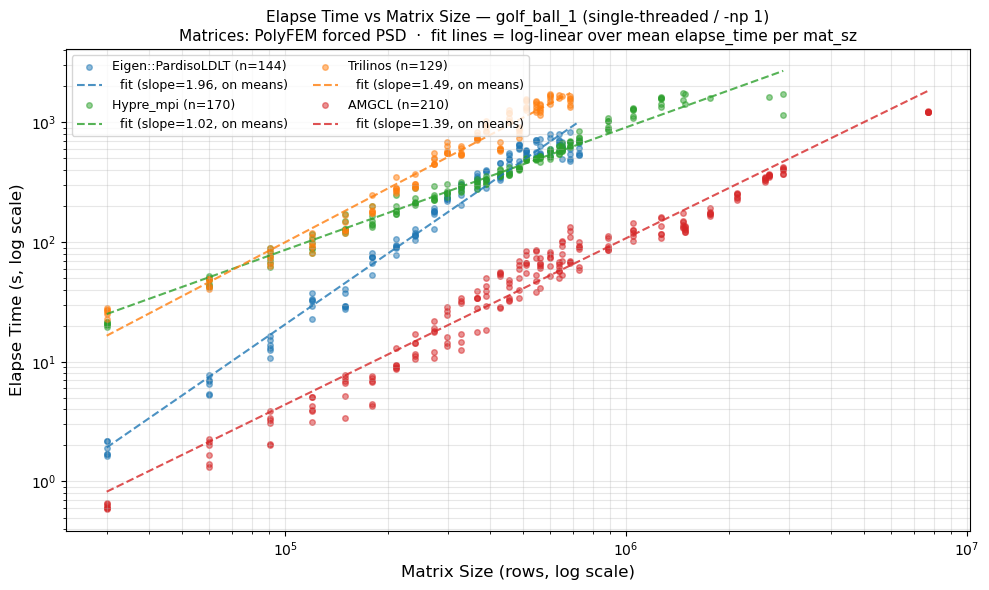

In [20]:
df1 = load_all_logs(os.path.join(BASE, 'golf_ball_1'))
print(f"Group golf_ball_1: {len(df1)} entries")
print(df1.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df1, 'Elapse Time vs Matrix Size — golf_ball_1 (single-threaded / -np 1)')
plt.show()

## Group 2: `golf_ball_8` — 8-way parallel

Group golf_ball_8: 773 entries
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210   49.427628
Eigen::PardisoLDLT  29988   727119   144   71.555836
Hypre_mpi           29988  7704660   210   50.169757
Trilinos            29988  7704660   209  107.913715


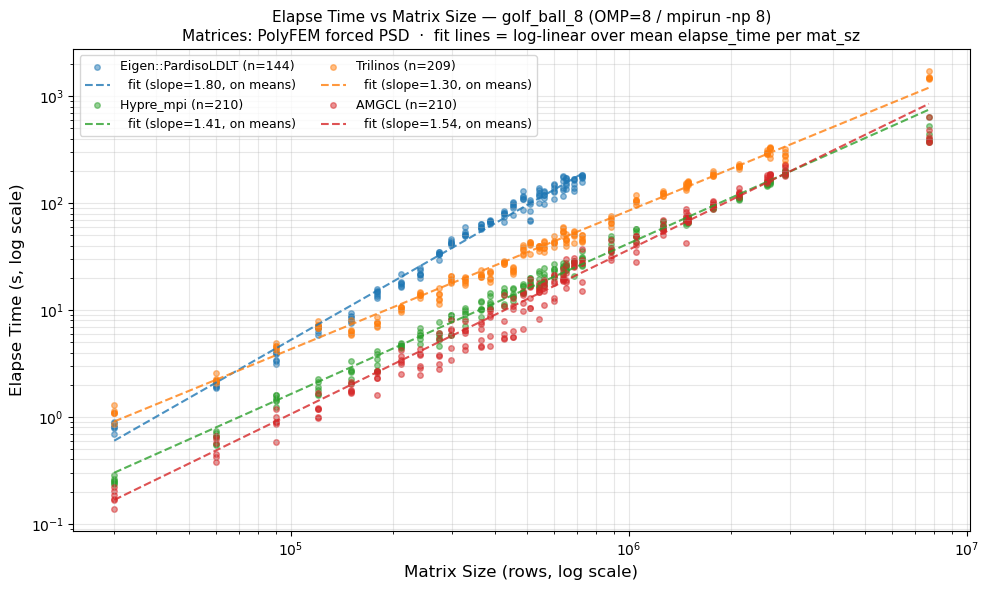

In [21]:
df8 = load_all_logs(os.path.join(BASE, 'golf_ball_8'))
print(f"Group golf_ball_8: {len(df8)} entries")
print(df8.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df8, 'Elapse Time vs Matrix Size — golf_ball_8 (OMP=8 / mpirun -np 8)')
plt.show()

### Iteration count vs Matrix Size — `golf_ball_8`

For iterative solvers, the iteration count tells us how convergence degrades as the system grows. Direct solvers (`Eigen::PardisoLDLT`) don't report iterations and are excluded.

Iterative entries in golf_ball_8: 629
          mat_sz                num_iterations              
             min      max count           mean   min     max
solver                                                      
AMGCL      29988  7704660   210       8.542857   4.0    22.0
Hypre_mpi  29988  7704660   210      93.800000  34.0   224.0
Trilinos   29988  7704660   209     114.559809  24.0  1000.0


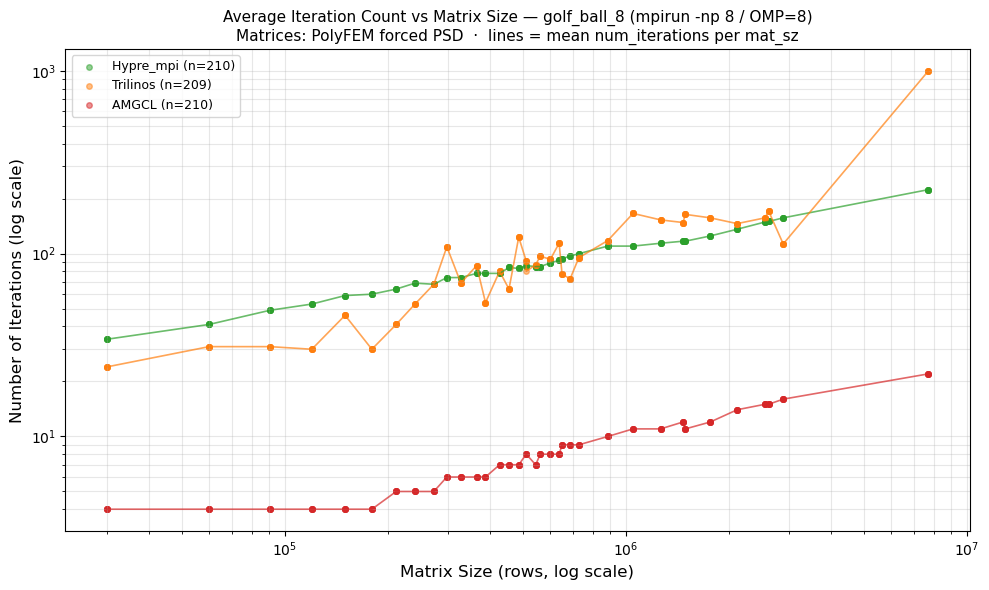

In [22]:
# Iterative solvers only — direct solvers don't report num_iterations
df8_iter = df8[df8['num_iterations'].notna() & (df8['solver'] != 'Eigen::PardisoLDLT')]
print(f"Iterative entries in golf_ball_8: {len(df8_iter)}")
print(df8_iter.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'num_iterations': ['mean', 'min', 'max']}))

fig, ax = plt.subplots(figsize=(10, 6))
for solver in SOLVER_PREFIXES:
    g = df8_iter[df8_iter['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    ax.scatter(g['mat_sz'], g['num_iterations'], s=16, alpha=0.5, color=color,
               label=f"{solver} (n={len(g)})")

    # Mean per mat_sz to show trend line
    g_mean = g.groupby('mat_sz')['num_iterations'].mean().reset_index().sort_values('mat_sz')
    if len(g_mean) >= 2:
        ax.plot(g_mean['mat_sz'], g_mean['num_iterations'], '-', color=color,
                linewidth=1.2, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Number of Iterations (log scale)', fontsize=12)
ax.set_title('Average Iteration Count vs Matrix Size — golf_ball_8 (mpirun -np 8 / OMP=8)\n'
             f'{DATA_SOURCE_NOTE}  ·  lines = mean num_iterations per mat_sz', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Parallel Speedup: `golf_ball_1` → `golf_ball_8`

For each solver and each matrix size, compute **speedup = mean(serial time) / mean(parallel-8 time)**. The ideal 8× speedup is shown as a dashed reference line. Values < 8 indicate parallel overhead / Amdahl bottleneck; values < 1 would mean the parallel version is actively slower.

Speedup rows (only mat_sz values present in BOTH groups): 118
                   mat_sz    speedup                      
                    count       mean        min        max
solver                                                    
AMGCL                  36   3.364812   1.788519   5.521928
Eigen::PardisoLDLT     25   4.746193   2.318122   6.823860
Hypre_mpi              33  31.988985   7.448319  80.762510
Trilinos               24  29.955243  13.720428  48.099548


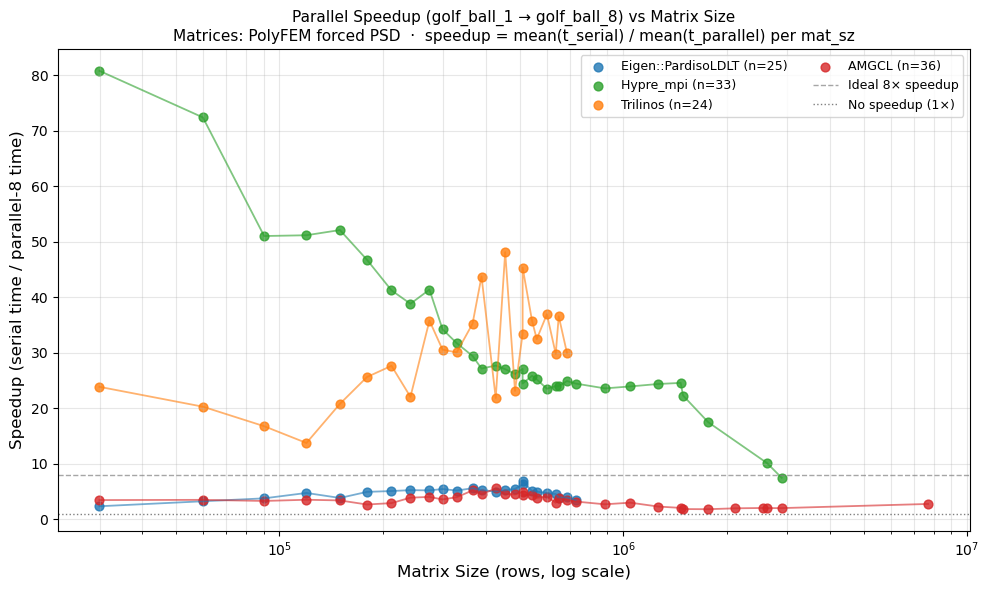

In [23]:
# Compute mean elapse_time per (solver, mat_sz), then join on matching keys.
mean1 = (df1.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
            .reset_index().rename(columns={'elapse_time': 'time_serial'}))
mean8 = (df8.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
            .reset_index().rename(columns={'elapse_time': 'time_parallel'}))

speedup_df = pd.merge(mean1, mean8, on=['solver', 'mat_sz'])
speedup_df['speedup'] = speedup_df['time_serial'] / speedup_df['time_parallel']
speedup_df = speedup_df.sort_values(['solver', 'mat_sz'])

print(f"Speedup rows (only mat_sz values present in BOTH groups): {len(speedup_df)}")
print(speedup_df.groupby('solver').agg({'mat_sz': 'count',
                                         'speedup': ['mean', 'min', 'max']}))

fig, ax = plt.subplots(figsize=(10, 6))
for solver in SOLVER_PREFIXES:
    g = speedup_df[speedup_df['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    ax.scatter(g['mat_sz'], g['speedup'], s=40, color=color, alpha=0.8,
               label=f"{solver} (n={len(g)})")
    ax.plot(g['mat_sz'], g['speedup'], '-', color=color, linewidth=1.3, alpha=0.6)

# Reference lines: ideal 8x and 1x (no speedup)
ax.axhline(y=8, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Ideal 8× speedup')
ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='No speedup (1×)')

ax.set_xscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Speedup (serial time / parallel-8 time)', fontsize=12)
ax.set_title('Parallel Speedup (golf_ball_1 → golf_ball_8) vs Matrix Size\n'
             f'{DATA_SOURCE_NOTE}  ·  speedup = mean(t_serial) / mean(t_parallel) per mat_sz',
             fontsize=11)
ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Re-run without `--oversubscribe` (serial baseline only)

The previous serial runs used `mpirun --oversubscribe -np 1`, which auto-enables `mpi_yield_when_idle`. Every `MPI_Allreduce` inside PCG yielded the CPU, and under concurrent benchmark load each yield cost tens to hundreds of microseconds waiting to be re-scheduled — bloating serial times by a large factor (especially for MPI solvers like Hypre_mpi and Trilinos).

Re-ran the `golf_ball_1` serial baseline **without `--oversubscribe`** (from `10000-2568220-no-oversubscribe/`). Parallel `-np 8` runs are unchanged because at np=8 the yields were picked up immediately by sibling ranks.

Below we compare:
1. **Old vs new serial time** — how much the oversubscribe flag was slowing serial runs
2. **Old vs new parallel speedup** — the corrected scaling numbers

In [24]:
# Load the new serial baseline (without --oversubscribe)
BASE_NEW = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220-no-oversubscribe'
df1_new = load_all_logs(os.path.join(BASE_NEW, 'golf_ball_1'))
print(f"New serial entries: {len(df1_new)}")
print(df1_new.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

# Compute mean elapse_time per (solver, mat_sz) for all three datasets
mean1_old = (df1.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
                .reset_index().rename(columns={'elapse_time': 't_serial_old'}))
mean1_new = (df1_new.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
                    .reset_index().rename(columns={'elapse_time': 't_serial_new'}))
mean8     = (df8.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
                .reset_index().rename(columns={'elapse_time': 't_parallel'}))

# Three-way join on (solver, mat_sz)
cmp = pd.merge(mean1_old, mean1_new, on=['solver', 'mat_sz'])
cmp = pd.merge(cmp, mean8, on=['solver', 'mat_sz'])
cmp['serial_inflation']  = cmp['t_serial_old'] / cmp['t_serial_new']   # how much oversubscribe slowed serial
cmp['speedup_old']       = cmp['t_serial_old'] / cmp['t_parallel']
cmp['speedup_new']       = cmp['t_serial_new'] / cmp['t_parallel']
cmp = cmp.sort_values(['solver', 'mat_sz']).reset_index(drop=True)
print(f"\nJoined rows: {len(cmp)}")

New serial entries: 685
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210   99.057539
Eigen::PardisoLDLT  29988   727119   144  220.382781
Hypre_mpi           29988  7704660   187  390.571800
Trilinos            29988   727119   144  433.106620

Joined rows: 118


### Plot 1 — Serial inflation from `--oversubscribe`

For each solver, plot `t_serial_old / t_serial_new` vs matrix size. A value of 1 means no inflation; higher values mean the old serial runs were artificially slowed down.

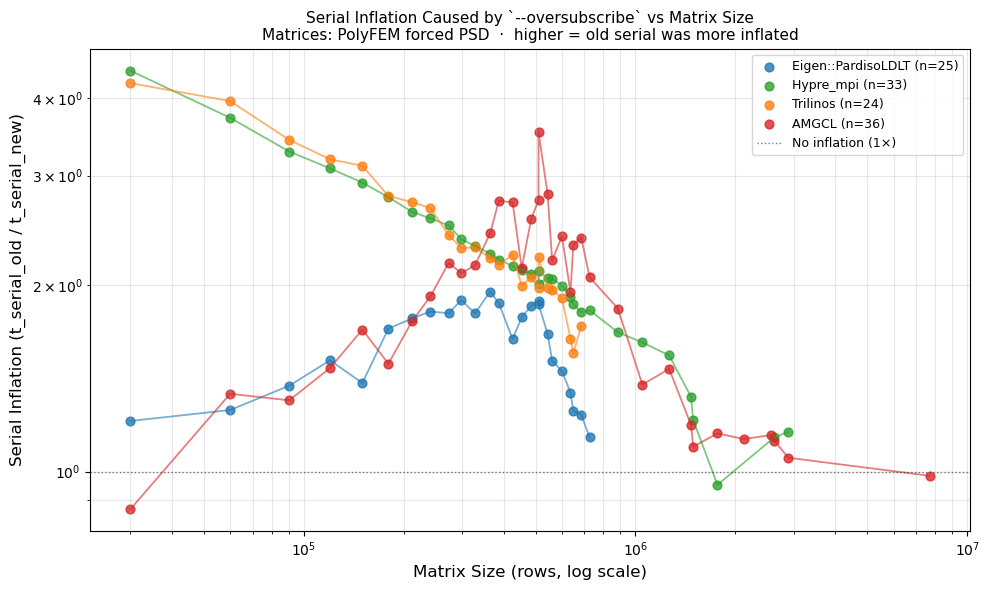

Mean serial inflation per solver:
                    mean   min   max
solver                              
AMGCL               1.85  0.87  3.53
Eigen::PardisoLDLT  1.60  1.14  1.95
Hypre_mpi           2.17  0.95  4.43
Trilinos            2.44  1.55  4.23


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
for solver in SOLVER_PREFIXES:
    g = cmp[cmp['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    ax.scatter(g['mat_sz'], g['serial_inflation'], s=40, color=color, alpha=0.8,
               label=f"{solver} (n={len(g)})")
    ax.plot(g['mat_sz'], g['serial_inflation'], '-', color=color, linewidth=1.3, alpha=0.6)

ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='No inflation (1×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Serial Inflation (t_serial_old / t_serial_new)', fontsize=12)
ax.set_title('Serial Inflation Caused by `--oversubscribe` vs Matrix Size\n'
             f'{DATA_SOURCE_NOTE}  ·  higher = old serial was more inflated',
             fontsize=11)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary per solver
print("Mean serial inflation per solver:")
print(cmp.groupby('solver')['serial_inflation'].agg(['mean', 'min', 'max']).round(2))

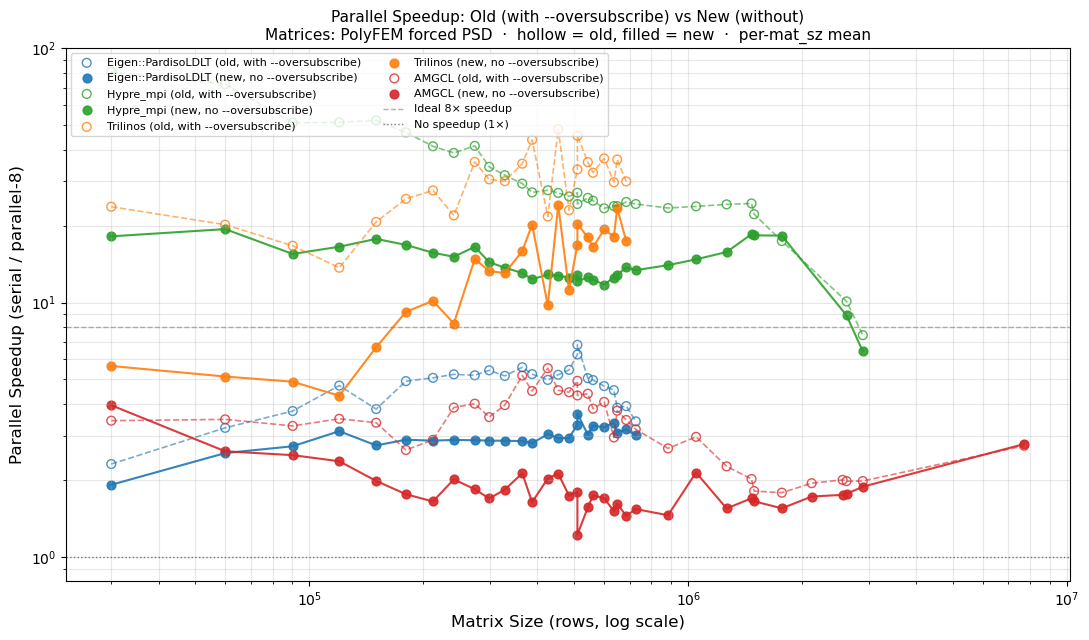

Speedup summary (old vs new):
                   speedup_old               speedup_new             
                          mean    min    max        mean   min    max
solver                                                               
AMGCL                     3.36   1.79   5.52        1.89  1.22   3.95
Eigen::PardisoLDLT        4.75   2.32   6.82        2.96  1.92   3.66
Hypre_mpi                31.99   7.45  80.76       14.34  6.42  19.46
Trilinos                 29.96  13.72  48.10       13.64  4.30  24.14


In [26]:
# Plot 2 — Old vs new parallel speedup on the same axes
fig, ax = plt.subplots(figsize=(11, 6.5))
for solver in SOLVER_PREFIXES:
    g = cmp[cmp['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    # Old speedup: dashed + hollow markers
    ax.plot(g['mat_sz'], g['speedup_old'], '--', color=color, linewidth=1.2, alpha=0.6)
    ax.scatter(g['mat_sz'], g['speedup_old'], s=40, facecolors='none', edgecolors=color,
               alpha=0.8, label=f"{solver} (old, with --oversubscribe)")
    # New speedup: solid + filled markers
    ax.plot(g['mat_sz'], g['speedup_new'], '-', color=color, linewidth=1.5, alpha=0.9)
    ax.scatter(g['mat_sz'], g['speedup_new'], s=40, color=color, alpha=0.9,
               label=f"{solver} (new, no --oversubscribe)")

ax.axhline(y=8, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Ideal 8× speedup')
ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='No speedup (1×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Parallel Speedup (serial / parallel-8)', fontsize=12)
ax.set_title('Parallel Speedup: Old (with --oversubscribe) vs New (without)\n'
             f'{DATA_SOURCE_NOTE}  ·  hollow = old, filled = new  ·  per-mat_sz mean',
             fontsize=11)
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary per solver
print("Speedup summary (old vs new):")
print(cmp.groupby('solver').agg({
    'speedup_old': ['mean', 'min', 'max'],
    'speedup_new': ['mean', 'min', 'max'],
}).round(2))

## Sanity check: `mpirun -np 1` vs direct invocation (isolated run)

**Question:** is `mpirun -np 1` itself adding significant overhead compared to just running the binary directly? When launched directly, `main_test_mat_logger.cpp`'s `MPI_Init()` enters **singleton mode** — `MPI_COMM_WORLD = {rank 0, size 1}`, collectives short-circuit to local ops, no `orterun` / PMI / yield machinery.

**Test setup:** machine relatively idle, single matrix `result_10000-2568220/129097/1_1_A.bin` (mat_sz = 387,291, ~3.7M NNZ), Hypre_mpi solver, `OMP_NUM_THREADS=1`, both commands wrapped in `numactl --cpunodebind=0 --membind=0`. 3 trials each.

### Raw timings

| Trial | Direct `factorize` | Direct `solve` | mpirun `factorize` | mpirun `solve` |
|:---:|---:|---:|---:|---:|
| 1 | 3.616 s | 11.905 s | 3.831 s | 12.282 s |
| 2 | 3.581 s | 11.944 s | 3.810 s | 12.267 s |
| 3 | 3.567 s | 11.978 s | 3.816 s | 12.250 s |
| **mean** | **3.588 s** | **11.942 s** | **3.819 s** | **12.266 s** |

### Per-phase overhead

| Phase | Direct (s) | mpirun -np 1 (s) | Δ | overhead |
|---|:---:|:---:|:---:|:---:|
| factorize | 3.59 | 3.82 | +0.23 | **+6.4 %** |
| solve | 11.94 | 12.27 | +0.33 | **+2.8 %** |
| **total elapse** | **15.53** | **16.09** | **+0.56** | **+3.6 %** |

PCG iterations were **42** in every run and `residual` was `1.18 × 10⁻¹⁷` in every run — numerically identical, only wall-clock differs.

### Takeaways

1. **`mpirun -np 1` has only ~3–6 % overhead in isolation**, nothing like the 20–40× inflation we originally observed in the concurrent benchmark data.
2. **The huge inflation in the original benchmark was NOT from `mpirun -np 1` intrinsically** — it was `--oversubscribe` auto-enabling `mpi_yield_when_idle`, making every `MPI_Allreduce` inside PCG call `sched_yield()`, and under heavy concurrent load each yield cost tens to hundreds of microseconds waiting to be re-scheduled.
3. **Removing `--oversubscribe` (the re-run above) is enough** to get trustworthy serial timings. Patching the benchmark to special-case `threads==1` (skip `mpirun`, invoke binary directly) would save another ~4 %, but that's small and not worth the code-path divergence.
4. **Singleton-mode MPI is real and works**: a binary that calls `MPI_Init()` can be launched directly without `mpirun` and operates as a 1-rank MPI world — all collectives short-circuit to local ops.

## Third re-run: `--no-oversubscribe` + NUMA binding

Hypothesis: for MPI solvers (`Hypre_mpi`, `Trilinos`), `mpirun -np 1` does **not** bind the process to a single NUMA node by default. The Linux scheduler may migrate it between sockets, and since the benchmark machine has 2 NUMA nodes (AMD EPYC 7452 × 2 sockets, cross-node access penalty 3.2×), migrations cause expensive remote memory accesses. When we compare this un-bound serial against the `-np 8` parallel run (which OpenMPI naturally spreads across both sockets), we get an artificial "super-linear" speedup — because parallel gets both sockets' bandwidth (~160 GB/s) while serial effectively loses NUMA locality.

**Fix**: prefix the serial command with `numactl --cpunodebind=0 --membind=0`, which
- pins CPU scheduling to NUMA node 0 (prevents migration)
- forces memory allocation onto node 0 (first-touch is deterministic)
- gives serial a consistent ~80 GB/s of local bandwidth

Re-ran `golf_ball_1` with this setting (data at `10000-2568220-no-oversubscribe-NUMA/`). Parallel `-np 8` is unchanged. Below we compare **all three serial baselines** against the same parallel reference:

1. `t_old` — `mpirun --oversubscribe -np 1`, no NUMA binding
2. `t_noovsub` — `mpirun -np 1`, no NUMA binding
3. `t_numa` — `numactl --cpunodebind=0 --membind=0 mpirun -np 1`

In [27]:
# Load the NUMA-bound serial baseline and build a 4-way comparison table
BASE_NUMA = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220-no-oversubscribe-NUMA'
df1_numa = load_all_logs(os.path.join(BASE_NUMA, 'golf_ball_1'))
print(f"NUMA serial entries: {len(df1_numa)}")
print(df1_numa.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

# Four-way join: old, no-oversubscribe, numa, parallel
mean_numa = (df1_numa.groupby(['solver', 'mat_sz'])['elapse_time'].mean()
                     .reset_index().rename(columns={'elapse_time': 't_numa'}))

cmp3 = pd.merge(mean1_old, mean1_new, on=['solver', 'mat_sz'])
cmp3 = pd.merge(cmp3, mean_numa, on=['solver', 'mat_sz'])
cmp3 = pd.merge(cmp3, mean8, on=['solver', 'mat_sz'])
cmp3 = cmp3.rename(columns={'t_serial_old': 't_old',
                            't_serial_new': 't_noovsub',
                            't_parallel':   't_par'})

cmp3['sp_old']     = cmp3['t_old']     / cmp3['t_par']
cmp3['sp_noovsub'] = cmp3['t_noovsub'] / cmp3['t_par']
cmp3['sp_numa']    = cmp3['t_numa']    / cmp3['t_par']
cmp3 = cmp3.sort_values(['solver', 'mat_sz']).reset_index(drop=True)

print(f"\nJoined rows (present in all 4 datasets): {len(cmp3)}")
print("\nMean speedup per solver (three serial baselines vs same parallel):")
summary = cmp3.groupby('solver').agg({
    'sp_old':     'mean',
    'sp_noovsub': 'mean',
    'sp_numa':    'mean',
    't_old':      'mean',
    't_noovsub':  'mean',
    't_numa':     'mean',
    't_par':      'mean',
}).round(2)
print(summary)

NUMA serial entries: 701
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210   99.899192
Eigen::PardisoLDLT  29988   727119   144  218.620549
Hypre_mpi           29988  2890827   203  293.495906
Trilinos            29988   727119   144  149.152772

Joined rows (present in all 4 datasets): 118

Mean speedup per solver (three serial baselines vs same parallel):
                    sp_old  sp_noovsub  sp_numa   t_old  t_noovsub  t_numa  \
solver                                                                       
AMGCL                 3.36        1.89     1.80  120.64      96.97   97.75   
Eigen::PardisoLDLT    4.75        2.96     2.93  346.82     223.84  222.26   
Hypre_mpi            31.99       14.34     6.26  613.64     404.75  234.49   
Trilinos             29.96       13.64     5.03  794.35     402.69  140.29   

                    t

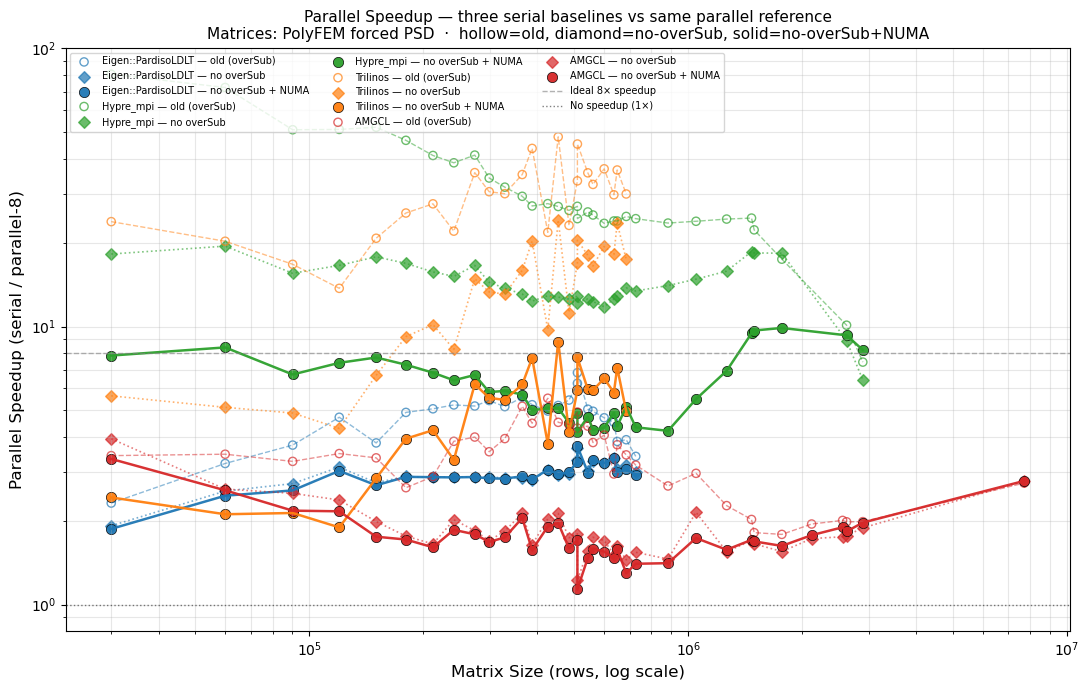

In [28]:
# Plot: three serial baselines vs same parallel, same axes
fig, ax = plt.subplots(figsize=(11, 7))

for solver in SOLVER_PREFIXES:
    g = cmp3[cmp3['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]

    # (1) Old: with --oversubscribe — dashed line + hollow circles
    ax.plot(g['mat_sz'], g['sp_old'], '--', color=color, linewidth=1.0, alpha=0.5)
    ax.scatter(g['mat_sz'], g['sp_old'], s=35, facecolors='none', edgecolors=color,
               alpha=0.7, label=f"{solver} — old (overSub)")

    # (2) no-oversubscribe — dotted line + diamond
    ax.plot(g['mat_sz'], g['sp_noovsub'], ':', color=color, linewidth=1.2, alpha=0.6)
    ax.scatter(g['mat_sz'], g['sp_noovsub'], s=35, marker='D', color=color,
               alpha=0.7, label=f"{solver} — no overSub")

    # (3) NUMA-bound — solid line + filled circle
    ax.plot(g['mat_sz'], g['sp_numa'], '-', color=color, linewidth=1.8, alpha=0.95)
    ax.scatter(g['mat_sz'], g['sp_numa'], s=55, color=color,
               alpha=0.95, edgecolors='black', linewidths=0.5,
               label=f"{solver} — no overSub + NUMA")

# Reference lines
ax.axhline(y=8, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Ideal 8× speedup')
ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='No speedup (1×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Parallel Speedup (serial / parallel-8)', fontsize=12)
ax.set_title('Parallel Speedup — three serial baselines vs same parallel reference\n'
             f'{DATA_SOURCE_NOTE}  ·  hollow=old, diamond=no-overSub, solid=no-overSub+NUMA',
             fontsize=11)
ax.legend(fontsize=7, loc='upper left', ncol=3)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### MPI solvers only — `Hypre_mpi` and `Trilinos`

Focused view of the two MPI-based solvers, which are the ones actually affected by the `mpirun` / NUMA issues. OMP solvers (`AMGCL`, `Eigen::PardisoLDLT`) are excluded here because their serial times barely changed across the three baselines.

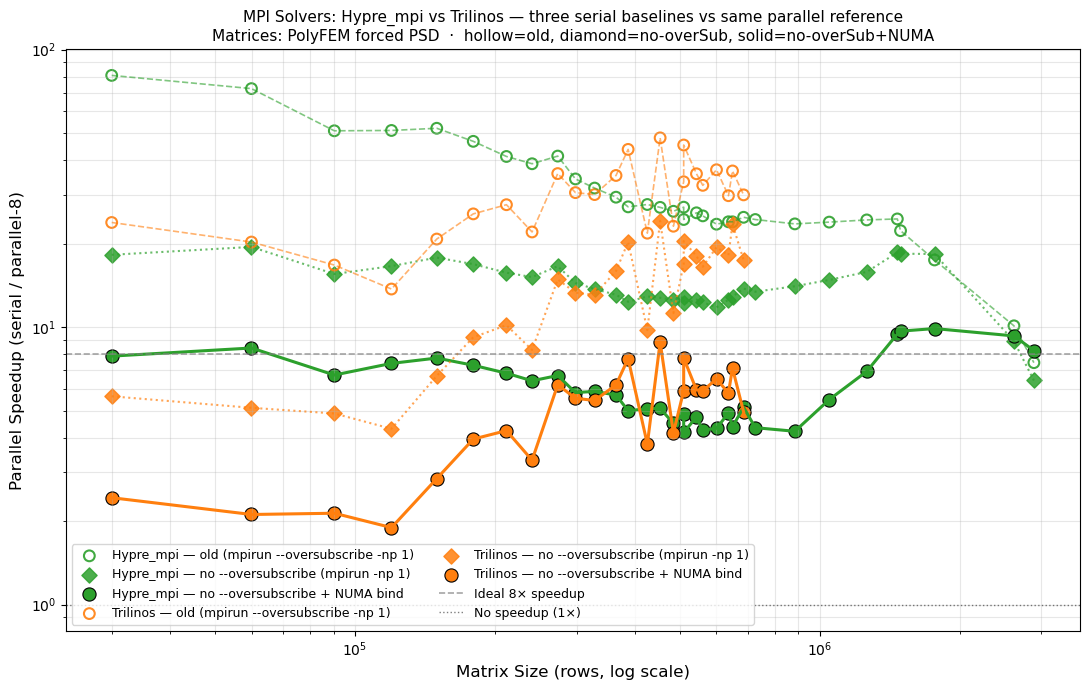


MPI solvers — mean speedup across mat_sz:
           sp_old  sp_noovsub  sp_numa
solver                                
Hypre_mpi   31.99       14.34     6.26
Trilinos    29.96       13.64     5.03


In [29]:
# Focused plot: Hypre_mpi and Trilinos only, three serial baselines
MPI_SOLVERS = ["Hypre_mpi", "Trilinos"]

fig, ax = plt.subplots(figsize=(11, 7))

for solver in MPI_SOLVERS:
    g = cmp3[cmp3['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]

    # (1) Old: with --oversubscribe — dashed line + hollow circles
    ax.plot(g['mat_sz'], g['sp_old'], '--', color=color, linewidth=1.2, alpha=0.6)
    ax.scatter(g['mat_sz'], g['sp_old'], s=60, facecolors='none', edgecolors=color,
               linewidths=1.5, alpha=0.9,
               label=f"{solver} — old (mpirun --oversubscribe -np 1)")

    # (2) no-oversubscribe — dotted line + diamond
    ax.plot(g['mat_sz'], g['sp_noovsub'], ':', color=color, linewidth=1.5, alpha=0.7)
    ax.scatter(g['mat_sz'], g['sp_noovsub'], s=60, marker='D', color=color,
               alpha=0.85,
               label=f"{solver} — no --oversubscribe (mpirun -np 1)")

    # (3) NUMA-bound — solid line + filled circle
    ax.plot(g['mat_sz'], g['sp_numa'], '-', color=color, linewidth=2.2, alpha=1.0)
    ax.scatter(g['mat_sz'], g['sp_numa'], s=90, color=color,
               alpha=1.0, edgecolors='black', linewidths=0.8,
               label=f"{solver} — no --oversubscribe + NUMA bind")

# Reference lines
ax.axhline(y=8, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Ideal 8× speedup')
ax.axhline(y=1, color='black', linestyle=':', linewidth=1, alpha=0.5, label='No speedup (1×)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Parallel Speedup (serial / parallel-8)', fontsize=12)
ax.set_title('MPI Solvers: Hypre_mpi vs Trilinos — three serial baselines vs same parallel reference\n'
             f'{DATA_SOURCE_NOTE}  ·  hollow=old, diamond=no-overSub, solid=no-overSub+NUMA',
             fontsize=11)
ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Print focused summary
print("\nMPI solvers — mean speedup across mat_sz:")
focus = cmp3[cmp3['solver'].isin(MPI_SOLVERS)].groupby('solver').agg({
    'sp_old':     'mean',
    'sp_noovsub': 'mean',
    'sp_numa':    'mean',
}).round(2)
print(focus)

## Sanity check: `mpirun -np 8` with vs without `--oversubscribe`

**Question:** the benchmark script still passes `--oversubscribe` to `mpirun` so that concurrent `mpirun` invocations via `ThreadPoolExecutor` don't fail OpenMPI's slot check. But does the flag's side effect (`mpi_yield_when_idle=1`) have any meaningful performance impact on the `-np 8` case itself? We already saw that for `-np 1` the impact was huge (because the single rank had nothing to yield to and got stuck waiting for rescheduling under concurrent load) — what about `-np 8`?

**Test setup:** machine relatively idle, single matrix `result_10000-2568220/129097/1_1_A.bin` (mat_sz = 387,291), Hypre_mpi solver, `OMP_NUM_THREADS=1`, 3 trials of each mode.

### Raw timings

| Trial | With `--oversubscribe` |  |  | Without `--oversubscribe` |  |  |
|:---:|---:|---:|---:|---:|---:|---:|
|  | factorize | solve | elapse | factorize | solve | elapse |
| 1 | 0.611 | 3.490 | 4.101 | 0.620 | 3.471 | 4.091 |
| 2 | 0.622 | 3.280 | 3.902 | 0.621 | 3.331 | 3.952 |
| 3 | 0.641 | 3.350 | 3.991 | 0.606 | 3.311 | 3.917 |
| **mean** | **0.625** | **3.373** | **3.998** | **0.616** | **3.371** | **3.987** |

### Difference

| Phase | With (s) | Without (s) | Δ | Relative |
|---|:---:|:---:|:---:|:---:|
| factorize | 0.625 | 0.616 | −0.009 | **−1.4 %** |
| solve | 3.373 | 3.371 | −0.002 | **−0.06 %** |
| **total elapse** | **3.998** | **3.987** | **−0.011** | **−0.3 %** |

`num_iterations = 78` and `residual = 1.17 × 10⁻¹⁷` in every run — numerically identical.

### Takeaways

1. **At `-np 8`, `--oversubscribe` has essentially zero performance impact.** The 0.3 % difference in total elapse is well below trial-to-trial noise (~5 %).
2. **Why:** at `-np 8` each rank owns its own core, so `sched_yield()` inside MPI collectives yields to "nothing in particular" (the sibling ranks are still computing on their own cores). The yielding rank is immediately rescheduled with negligible delay.
3. **Contrast with `-np 1`:** for the serial case each yield gave the CPU to some unrelated task on the machine and had to wait tens-to-hundreds of microseconds to be rescheduled — this bloated serial times massively under concurrent benchmark load. That asymmetry (`-np 1` suffers, `-np 8` does not) is what made the old uncorrected speedup look 20–80×.
4. **Why we keep `--oversubscribe` in the benchmark script:** not because we actually need to oversubscribe, but because the `ThreadPoolExecutor`-based driver launches many `mpirun` instances concurrently, and without the flag OpenMPI's slot check can refuse a concurrent launch even when the machine as a whole has plenty of free cores. Since the flag is performance-neutral at `-np 8`, keeping it does no harm.